# Hotel Ranking — LambdaMART + Bias Analysis
---

# Part A — LambdaMART Modelling

## 0 · Install dependencies & imports

In [1]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from scipy.stats import kendalltau
import gc

## 1 · Data loading

In [ ]:
all_cols = pd.read_csv("training_full.csv", nrows=0).columns.tolist()

META = {"srch_id", "split", "relevance", "click_bool", "booking_bool"}
FEATURES = [c for c in all_cols if c not in META]

# ── read with float32 to halve memory ──
dtypes = {c: np.float32 for c in FEATURES}
dtypes.update({"relevance": np.int8, "click_bool": np.int8, "booking_bool": np.int8})

train_df = pd.read_csv("training_full.csv", dtype=dtypes)
print(f"Loaded: {train_df.shape}  |  {train_df.memory_usage(deep=True).sum()/1e6:.0f} MB")

# ── split ──
df_train = train_df[train_df["split"] == "train"]
df_val   = train_df[train_df["split"] == "val"]

print(f"train_df : {df_train.shape}")
print(f"val_df   : {df_val.shape}")
print(f"Features : {len(FEATURES)}")

Loaded: (4958347, 67)  |  1590 MB
train_df : (4214178, 67)
val_df   : (744169, 67)
Features : 62


### 1a · Quick data check

In [3]:
rel_counts = train_df["relevance"].value_counts().sort_index()
print("Relevance distribution:")
print(rel_counts.to_string())
print(f"\nBooking rate : {(train_df['relevance']==5).mean()*100:.2f}%")
print(f"Click rate   : {(train_df['relevance']==1).mean()*100:.2f}%")

leakage_cols = {"booking_bool", "click_bool", "position",
                "gross_booking_usd", "relevance"}
leaked = leakage_cols.intersection(set(FEATURES))
if leaked:
    raise ValueError(f"Leakage columns found in FEATURES: {leaked}")
print("\nLeakage check passed — no label columns in FEATURES.")

Relevance distribution:
relevance
0    4736468
1      83489
5     138390

Booking rate : 2.79%
Click rate   : 1.68%

Leakage check passed — no label columns in FEATURES.


## 2 · Build group arrays

LightGBM reads groups as **contiguous row blocks**.
Rows **must be sorted by `srch_id`** before computing group sizes.

In [4]:
df_train = df_train.sort_values("srch_id").reset_index(drop=True)
df_val   = df_val.sort_values("srch_id").reset_index(drop=True)

train_groups = df_train.groupby("srch_id", sort=False).size().values
val_groups   = df_val.groupby("srch_id",   sort=False).size().values

print(f"Sample group sizes (first 8): {train_groups[:8]}")
print(f"Min / max hotels per search  : {train_groups.min()} / {train_groups.max()}")
print(f"Sum of groups == nrows       : {train_groups.sum() == len(df_train)}")

Sample group sizes (first 8): [28 32  5 21 33 31 29 33]
Min / max hotels per search  : 5 / 38
Sum of groups == nrows       : True


## 3 · Create LightGBM datasets

In [5]:
X_train = df_train[FEATURES]
y_train = df_train["relevance"]
X_val   = df_val[FEATURES]
y_val   = df_val["relevance"]

lgb_train = lgb.Dataset(X_train, label=y_train,
                         group=train_groups, free_raw_data=False)
lgb_val   = lgb.Dataset(X_val,   label=y_val,
                         group=val_groups, reference=lgb_train,
                         free_raw_data=False)
print("LightGBM datasets created.")

LightGBM datasets created.


## 4 · Hyperparameters

In [6]:
params = {
    "objective"                  : "lambdarank",
    "metric"                     : "ndcg",
    "ndcg_eval_at"               : [5],
    "num_leaves"                 : 63,
    "learning_rate"              : 0.05,
    "min_data_in_leaf"           : 20,
    "feature_fraction"           : 0.8,
    "bagging_fraction"           : 0.8,
    "bagging_freq"               : 5,
    "lambdarank_truncation_level": 10,
    "verbose"                    : -1,
    "n_jobs"                     : -1,
}
print("Parameters set.")

Parameters set.


## 5 · Train with early stopping

Early stopping monitors val NDCG@5 and halts when it hasn't improved
for `stopping_rounds` consecutive rounds.

In [7]:
callbacks = [
    lgb.early_stopping(stopping_rounds=30, verbose=True),
    lgb.log_evaluation(period=50),
]

model = lgb.train(
    params, lgb_train,
    num_boost_round=500,
    valid_sets=[lgb_val], valid_names=["val"],
    callbacks=callbacks,
)

print(f"\nBest iteration  : {model.best_iteration}")
print(f"Best NDCG@5     : {model.best_score['val']['ndcg@5']:.4f}")

Training until validation scores don't improve for 30 rounds
[50]	val's ndcg@5: 0.375436
[100]	val's ndcg@5: 0.379297
[150]	val's ndcg@5: 0.381907
[200]	val's ndcg@5: 0.384479
[250]	val's ndcg@5: 0.385367
[300]	val's ndcg@5: 0.386089
[350]	val's ndcg@5: 0.386484
Early stopping, best iteration is:
[334]	val's ndcg@5: 0.38667

Best iteration  : 334
Best NDCG@5     : 0.3867


## 6 · Tuning hyperparameters

In [8]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [12]:
# Rebuild datasets with feature_pre_filter disabled
# (required when min_data_in_leaf is tuned across trials)
# No params= on the Dataset
lgb_train_opt = lgb.Dataset(
    X_train, label=y_train,
    group=train_groups,
    free_raw_data=False,
)
lgb_val_opt = lgb.Dataset(
    X_val, label=y_val,
    group=val_groups,
    reference=lgb_train_opt,
    free_raw_data=False,
)

Running 30 Optuna trials on val NDCG@5 ...


  0%|          | 0/30 [00:00<?, ?it/s]


Best NDCG@5      : 0.3883
Best iteration   : 471

Best hyperparameters:
  num_leaves                           = 63
  learning_rate                        = 0.03842003835238006
  min_data_in_leaf                     = 117
  feature_fraction                     = 0.8104531856045132
  bagging_fraction                     = 0.7438197088414235
  lambdarank_truncation_level          = 11
  reg_alpha                            = 0.000319445039939964
  reg_lambda                           = 0.00029523728908595163


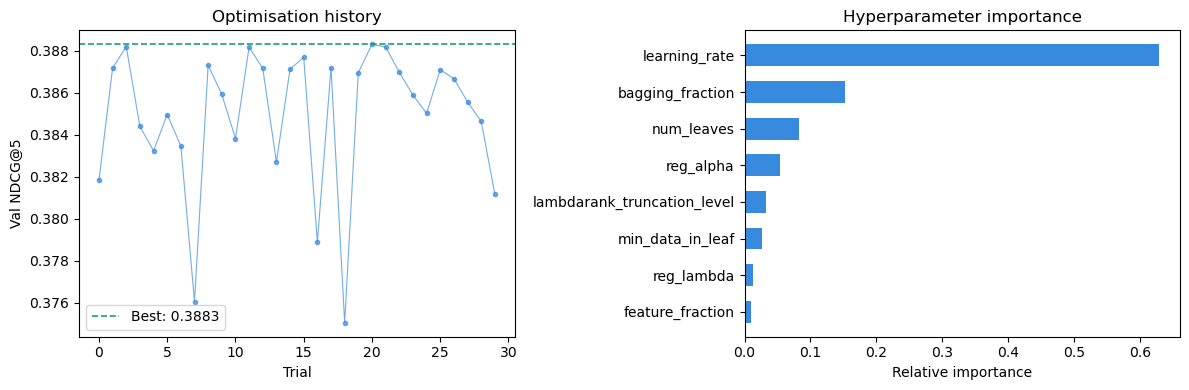

Saved: optuna_tuning.png

Retraining final model with best parameters ...
Training until validation scores don't improve for 30 rounds
[50]	val's ndcg@5: 0.373424
[100]	val's ndcg@5: 0.37626
[150]	val's ndcg@5: 0.379238
[200]	val's ndcg@5: 0.38171
[250]	val's ndcg@5: 0.383768
[300]	val's ndcg@5: 0.385355
[350]	val's ndcg@5: 0.386105
[400]	val's ndcg@5: 0.387526
[450]	val's ndcg@5: 0.388114
[500]	val's ndcg@5: 0.388241
Did not meet early stopping. Best iteration is:
[471]	val's ndcg@5: 0.388308

Final model — best iteration : 471
Final model — val NDCG@5     : 0.3883
Saved: lambdamart_tuned.txt


In [ ]:
N_TRIALS = 30   # reduce to 20 for a quick run, increase to 100 for more thorough search

def objective(trial: optuna.Trial) -> float:
    trial_params = {
        "objective"          : "lambdarank",
        "metric"             : "ndcg",
        "ndcg_eval_at"       : [5],
        "bagging_freq"       : 5,
        "verbose"            : -1,
        "n_jobs"             : -1,
        "feature_pre_filter" : False,   # ← back in trial_params, consistent across all trials

        "num_leaves"         : trial.suggest_int("num_leaves", 31, 255, step=16),
        "learning_rate"      : trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
        "min_data_in_leaf"   : trial.suggest_int("min_data_in_leaf", 10, 200, log=True),
        "feature_fraction"   : trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction"   : trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "lambdarank_truncation_level": trial.suggest_int("lambdarank_truncation_level", 5, 20),
        "reg_alpha"          : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"         : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
    }

    m = lgb.train(
        trial_params,
        lgb_train_opt,       # ← use new dataset
        num_boost_round=500,
        valid_sets=[lgb_val_opt],   # ← use new dataset
        valid_names=["val"],
        callbacks=[
            lgb.early_stopping(stopping_rounds=30, verbose=False),
            lgb.log_evaluation(period=9999),
        ],
    )
    trial.set_user_attr("best_iteration", m.best_iteration)
    return m.best_score["val"]["ndcg@5"]


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)

print(f"Running {N_TRIALS} Optuna trials on val NDCG@5 ...")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)


print(f"\nBest NDCG@5      : {study.best_value:.4f}")
print(f"Best iteration   : {study.best_trial.user_attrs['best_iteration']}")
print("\nBest hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k:<36} = {v}")


# Plot 1: optimisation history — did NDCG improve over trials?
vals = [t.value for t in study.trials if t.value is not None]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(vals, marker="o", markersize=3, linewidth=0.8, color="#378ADD", alpha=0.7)
axes[0].axhline(study.best_value, color="#1D9E75", linestyle="--", linewidth=1.2,
                label=f"Best: {study.best_value:.4f}")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Val NDCG@5")
axes[0].set_title("Optimisation history")
axes[0].legend()

# Plot 2: parameter importance
importance = optuna.importance.get_param_importances(study)
imp_names  = list(importance.keys())[:8]
imp_vals   = [importance[k] for k in imp_names]
axes[1].barh(imp_names[::-1], imp_vals[::-1], color="#378ADD", height=0.6)
axes[1].set_xlabel("Relative importance")
axes[1].set_title("Hyperparameter importance")

plt.tight_layout()
plt.savefig("optuna_tuning.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: optuna_tuning.png")

# ═══════════════════════════════════════════════════════════════════════════
# FINAL MODEL — retrain from scratch using best hyperparameters
# ═══════════════════════════════════════════════════════════════════════════

best_params = {
    # Fixed structural params
    "objective"   : "lambdarank",
    "metric"      : "ndcg",
    "ndcg_eval_at": [5],
    "bagging_freq": 5,
    "verbose"     : -1,
    "n_jobs"      : -1,
    # Injected best values from Optuna
    **study.best_params,
}

print("\nRetraining final model with best parameters ...")
model = lgb.train(
    best_params,
    lgb_train,
    num_boost_round=500,
    valid_sets=[lgb_val],
    valid_names=["val"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=True),
        lgb.log_evaluation(period=50),
    ],
)

print(f"\nFinal model — best iteration : {model.best_iteration}")
print(f"Final model — val NDCG@5     : {model.best_score['val']['ndcg@5']:.4f}")

# Save the tuned model
model.save_model("lambdamart_tuned.txt")
print("Saved: lambdamart_tuned.txt")

## 7 · Feature importance

`gain` = total NDCG improvement contributed by each feature across all trees.

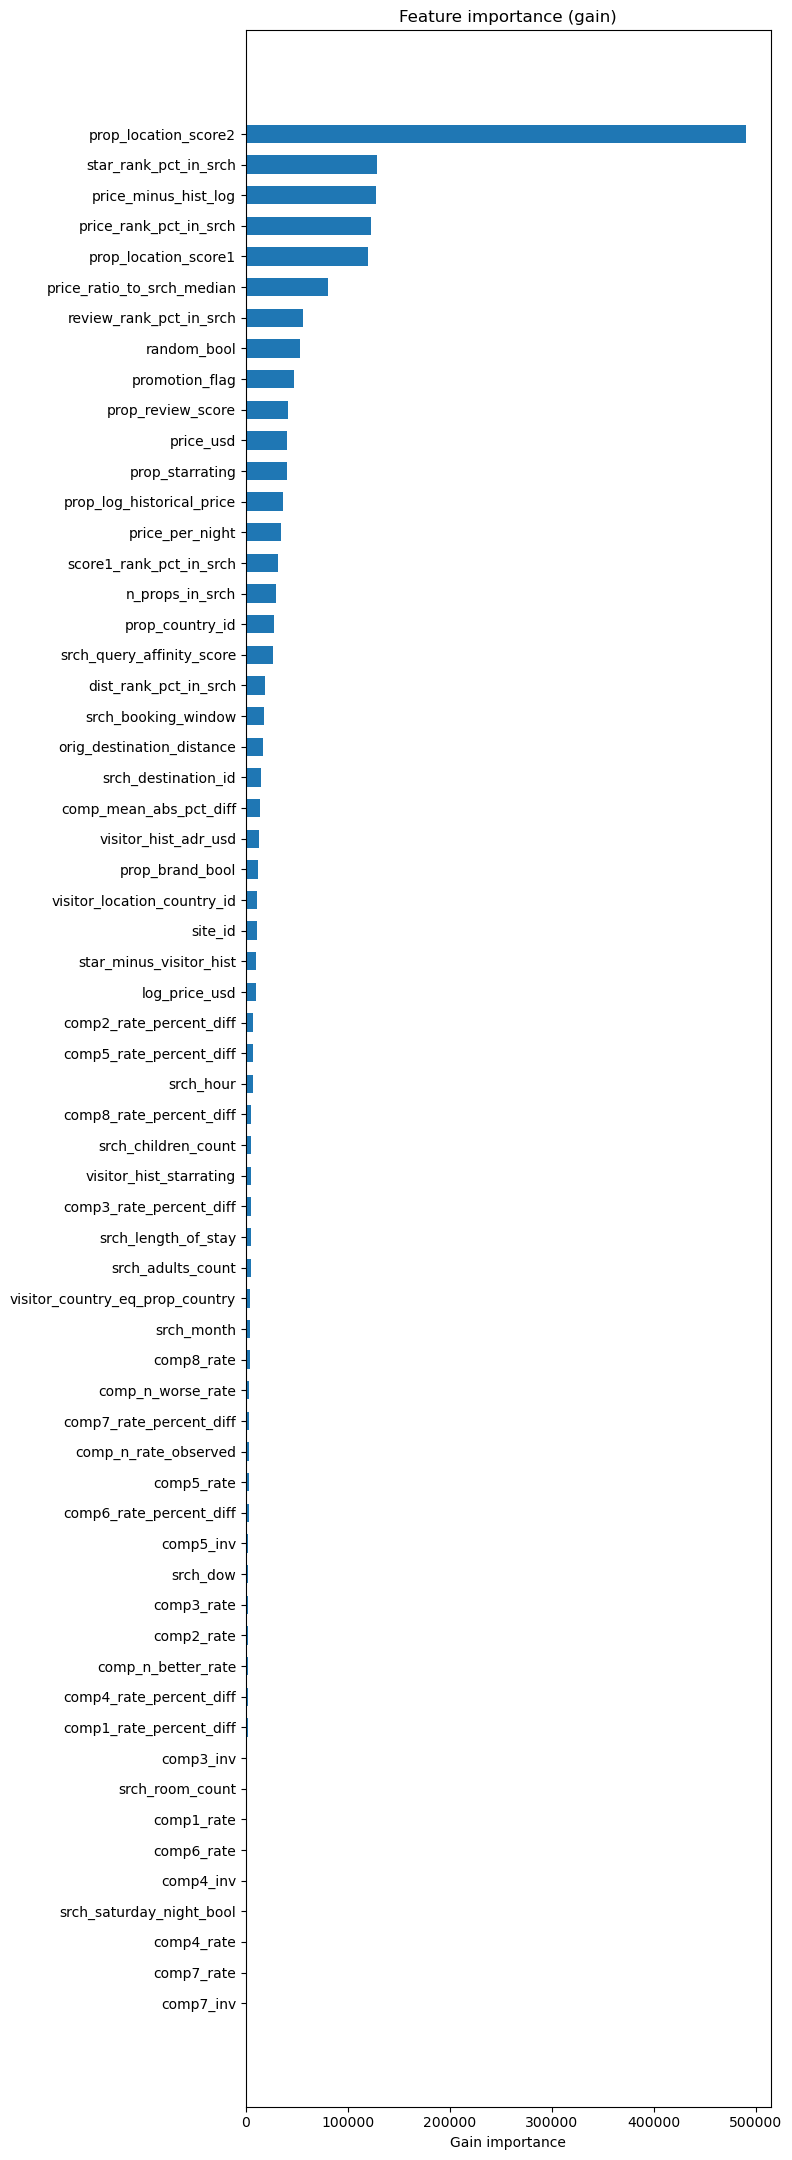

                        feature    importance
           prop_location_score2 489728.986375
          star_rank_pct_in_srch 128786.592719
           price_minus_hist_log 127619.846925
         price_rank_pct_in_srch 122874.967341
           prop_location_score1 119758.611398
     price_ratio_to_srch_median  80300.632692
        review_rank_pct_in_srch  55899.215330
                    random_bool  52715.551680
                 promotion_flag  47308.187120
              prop_review_score  41404.421078
                      price_usd  40358.525335
                prop_starrating  40116.131343
      prop_log_historical_price  36537.020523
                price_per_night  33877.621606
        score1_rank_pct_in_srch  31748.874589
                n_props_in_srch  29248.099547
                prop_country_id  27277.634186
      srch_query_affinity_score  26343.568806
          dist_rank_pct_in_srch  18302.572926
            srch_booking_window  18068.186395
      orig_destination_distance  1

In [14]:
importance = (
    pd.DataFrame({
        "feature"   : model.feature_name(),
        "importance": model.feature_importance(importance_type="gain"),
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(8, max(3, len(FEATURES) * 0.35)))
ax.barh(importance["feature"][::-1], importance["importance"][::-1], height=0.6)
ax.set_xlabel("Gain importance")
ax.set_title("Feature importance (gain)")
plt.tight_layout()
plt.show()

print(importance.to_string(index=False))

## 8 · Manual NDCG@5 evaluation

In [15]:
def dcg_at_k(relevances, k=5):
    relevances = np.array(relevances[:k], dtype=float)
    if len(relevances) == 0:
        return 0.0
    return np.sum(relevances / np.log2(np.arange(1, len(relevances)+1) + 1))

def ndcg_at_k(relevances, k=5):
    idcg = dcg_at_k(sorted(relevances, reverse=True), k)
    return 1.0 if idcg == 0 else dcg_at_k(relevances, k) / idcg

df_val_scored = df_val.copy()
df_val_scored["pred_score"] = model.predict(X_val)

ndcg_per_search = []
for _, grp in df_val_scored.groupby("srch_id"):
    ranked = grp.sort_values("pred_score", ascending=False)["relevance"].tolist()
    ndcg_per_search.append(ndcg_at_k(ranked, k=5))

ndcg_values = np.array(ndcg_per_search)
print(f"NDCG@5  mean   : {ndcg_values.mean():.4f}")
print(f"NDCG@5  median : {np.median(ndcg_values):.4f}")
print(f"NDCG@5  std    : {ndcg_values.std():.4f}")
print(f"Searches scored: {len(ndcg_values):,}")

NDCG@5  mean   : 0.3888
NDCG@5  median : 0.3869
NDCG@5  std    : 0.3842
Searches scored: 29,970


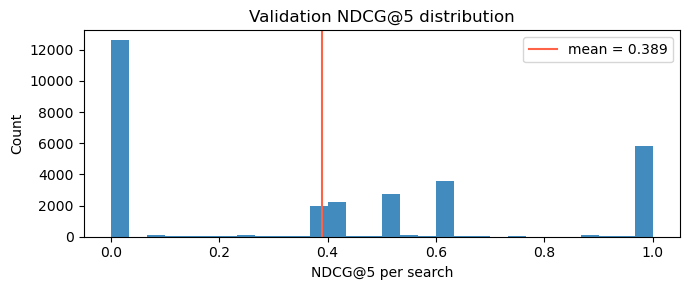

In [16]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(ndcg_values, bins=30, edgecolor="none", alpha=0.85)
ax.axvline(ndcg_values.mean(), color="tomato", linewidth=1.5,
           label=f"mean = {ndcg_values.mean():.3f}")
ax.set_xlabel("NDCG@5 per search")
ax.set_ylabel("Count")
ax.set_title("Validation NDCG@5 distribution")
ax.legend()
plt.tight_layout()
plt.show()

## 9 · Generate submission file

Score every row in `test_df`, sort descending by score within each `srch_id`,
and write the `SearchId, PropertyId` CSV.

In [ ]:
TEST_FEATURES_PATH = "test_features.csv"   # written by preprocessing Cell B

test_cols   = pd.read_csv(TEST_FEATURES_PATH, nrows=0).columns.tolist()
test_dtypes = {c: np.float32 for c in test_cols
               if c not in {"srch_id", "prop_id"}}

print(f"Loading {TEST_FEATURES_PATH} ...")
test_df = pd.read_csv(TEST_FEATURES_PATH, dtype=test_dtypes)
print(f"  shape : {test_df.shape}")

# Score and rank 
X_test = test_df[FEATURES]   # FEATURES defined in Section 1
test_df["pred_score"] = model.predict(X_test)

submission = (
    test_df[["srch_id", "prop_id", "pred_score"]]
    .sort_values(["srch_id", "pred_score"], ascending=[True, False])
    .drop(columns=["pred_score"])
    .rename(columns={"srch_id": "SearchId", "prop_id": "PropertyId"})
    .reset_index(drop=True)
)

submission.to_csv("submission.csv", index=False)
print(f"\nSaved submission.csv")
print(f"  Total rows      : {len(submission):,}")
print(f"  Unique searches : {submission['SearchId'].nunique():,}")
print(submission.head(12).to_string(index=False))

Loading test_features.csv ...
  shape : (4959183, 64)

Saved submission.csv
  Total rows      : 4,959,183
  Unique searches : 199,549
 SearchId  PropertyId
        1       99484
        1       54937
        1       61934
        1       28181
        1       24194
        1       34263
        1       63894
        1       82231
        1       50162
        1       90385
        1       72090
        1       78599


## 10 · Save and reload the model

In [18]:
model.save_model("lambdamart_model.txt")
print("Model saved to lambdamart_model.txt")

# To reload later:
# model = lgb.Booster(model_file="lambdamart_model.txt")

Model saved to lambdamart_model.txt


---
# Part B — Task 5: Position Bias Detection and Mitigation

**Position bias:** hotels shown at higher positions by Expedia receive more
clicks/bookings because users see them first — not because they are objectively better.
A model trained without correction learns to favour whatever Expedia already ranked highly.

**Mitigation:** Inverse Propensity Scoring (IPS) — a pre-processing technique that
re-weights each training example by the inverse probability of it being seen at its
displayed position.

> **Reference:** Joachims et al. (2017) *Unbiased Learning-to-Rank with Biased Feedback*. WSDM 2017.

---

## 11 · Detect position bias

Compute click and booking rate at each display position.
A clear declining trend is statistical evidence of position bias.

In [ ]:
RAW_TRAIN = "training_set_VU_DM.csv"   

print("Loading position data from raw CSV ...")
bias_all = pd.read_csv(
    RAW_TRAIN,
    usecols=["srch_id", "prop_id", "position", "booking_bool", "click_bool"],
    dtype={
        "srch_id"     : "int32",
        "prop_id"     : "int32",
        "position"    : "float32",
        "booking_bool": "int8",
        "click_bool"  : "int8",
    },
)
print(f"  bias_all shape : {bias_all.shape}")

# Split into train / val using the same srch_id split as the model
train_srch_ids = set(df_train["srch_id"].unique())
val_srch_ids   = set(df_val["srch_id"].unique())

bias_train = bias_all[bias_all["srch_id"].isin(train_srch_ids)].copy()
bias_val   = bias_all[bias_all["srch_id"].isin(val_srch_ids)].copy()
gc.collect()

print(f"  bias_train : {bias_train.shape}")
print(f"  bias_val   : {bias_val.shape}")

Loading position data from raw CSV ...
  bias_all shape : (4958347, 5)
  bias_train : (4214178, 5)
  bias_val   : (744169, 5)


pos_bin  n_rows  click_rate  booking_rate
    1–3  508413    0.143911      0.101968
    4–8  668944    0.067834      0.042966
   9–15  903339    0.036817      0.021065
  16–25 1037552    0.021450      0.010855
    26+ 1095930    0.013416      0.006161


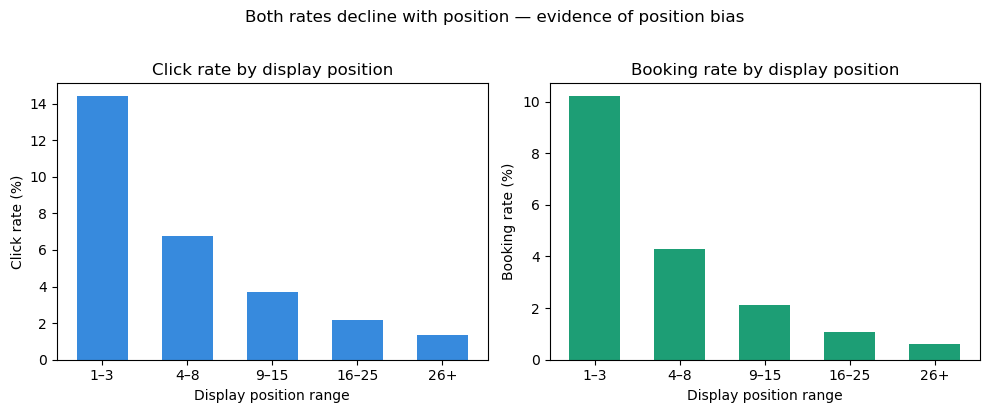


Kendall τ (position vs click_bool)   : -0.1425  p=0.00e+00
Kendall τ (position vs booking_bool) : -0.1282  p=0.00e+00


In [ ]:
# Bin positions into meaningful ranges
bins   = [0, 3, 8, 15, 25, float("inf")]
labels = ["1–3", "4–8", "9–15", "16–25", "26+"]

bias_train["pos_bin"] = pd.cut(
    bias_train["position"], bins=bins, labels=labels
)

position_stats = (
    bias_train.groupby("pos_bin", observed=True)
    .agg(
        n_rows       = ("srch_id",      "count"),
        click_rate   = ("click_bool",   "mean"),
        booking_rate = ("booking_bool", "mean"),
    )
    .reset_index()
)
print(position_stats.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(labels, position_stats["click_rate"]   * 100, color="#378ADD", width=0.6)
axes[0].set_xlabel("Display position range")
axes[0].set_ylabel("Click rate (%)")
axes[0].set_title("Click rate by display position")

axes[1].bar(labels, position_stats["booking_rate"] * 100, color="#1D9E75", width=0.6)
axes[1].set_xlabel("Display position range")
axes[1].set_ylabel("Booking rate (%)")
axes[1].set_title("Booking rate by display position")

plt.suptitle("Both rates decline with position — evidence of position bias", y=1.02)
plt.tight_layout()
plt.savefig("bias_detection.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
tau_c, p_c = kendalltau(bias_train["position"], bias_train["click_bool"])
tau_b, p_b = kendalltau(bias_train["position"], bias_train["booking_bool"])

print(f"\nKendall τ (position vs click_bool)   : {tau_c:.4f}  p={p_c:.2e}")
print(f"Kendall τ (position vs booking_bool) : {tau_b:.4f}  p={p_b:.2e}")

if p_c < 0.05 and tau_c < 0:
    print("✓ Significant negative τ — position bias confirmed in click labels.")
if p_b < 0.05 and tau_b < 0:
    print("✓ Significant negative τ — position bias confirmed in booking labels.")


Kendall τ (position vs click_bool)   : -0.1425  p=0.00e+00
Kendall τ (position vs booking_bool) : -0.1282  p=0.00e+00
✓ Significant negative τ — position bias confirmed in click labels.
✓ Significant negative τ — position bias confirmed in booking labels.


## 12 · Define fairness groups

Label every search by where the booked hotel originally appeared in Expedia's list.

| Group | Booked hotel's original position | Visibility |
|---|---|---|
| A | 1–3 | High — shown near top |
| B | 4–10 | Medium — mid-page |
| C | 11+ | Low — buried at bottom |

In [ ]:
def assign_group(pos):
    if pos <= 3:    return "A (pos 1–3)"
    elif pos <= 10: return "B (pos 4–10)"
    else:           return "C (pos 11+)"

booked_positions = (
    bias_all[bias_all["booking_bool"] == 1]
    [["srch_id", "position"]]
    .rename(columns={"position": "booked_pos"})
)

def add_group_labels(df: pd.DataFrame) -> pd.DataFrame:
    out = df.merge(booked_positions, on="srch_id", how="left")
    out["pos_group"] = out["booked_pos"].fillna(999).astype(int).apply(assign_group)
    return out

df_val_grp = add_group_labels(df_val.copy())

print("Validation searches per fairness group:")
print(
    df_val_grp.drop_duplicates("srch_id")["pos_group"]
    .value_counts().sort_index().to_string()
)

Validation searches per fairness group:
pos_group
A (pos 1–3)      9186
B (pos 4–10)     6515
C (pos 11+)     14269


## 13 · Compute IPS sample weights

**Propensity** = probability a hotel at position *k* is examined: `propensity(k) = 1/k`

**IPS weight** = `1 / propensity(k) = k`

Hotels at position 8 get 8× the weight of position-1 hotels, correcting for their
reduced visibility. Weights are normalised within each search so the mean weight
per search equals 1.

In [ ]:
df_train_s   = df_train.sort_values("srch_id").reset_index(drop=True)
bias_train_s = bias_train.sort_values("srch_id").reset_index(drop=True)

assert (df_train_s["srch_id"].values == bias_train_s["srch_id"].values).all(), \
    "Row alignment failed."

df_train_s = df_train_s.copy()
df_train_s["position"] = bias_train_s["position"].values

# IPS weight = position
# Hotels shown at position 35 now get 35× more weight than position 1
df_train_s["ips_weight"] = (
    df_train_s["position"]
    .fillna(df_train_s["position"].median())   # fill missing with median
)

# Normalise within each search so mean weight per search = 1
df_train_s["ips_weight"] = (
    df_train_s.groupby("srch_id")["ips_weight"]
    .transform(lambda x: x / x.mean())
)

print("IPS weight statistics (no truncation):")
print(df_train_s["ips_weight"].describe().round(3).to_string())
print(f"\nMax position in data : {df_train_s['position'].max():.0f}")
print(f"Max IPS weight       : {df_train_s['ips_weight'].max():.2f}")

IPS weight statistics (no truncation):
count    4214178.000
mean           1.000
std            0.558
min            0.042
25%            0.501
50%            1.020
75%            1.493
max            4.000

Max position in data : 40
Max IPS weight       : 4.00


## 14 · Build LightGBM datasets for bias comparison

The only difference between the two datasets is `weight=w_ips`.
Everything else — features, hyperparameters, early stopping — is identical
so the comparison is clean.

In [24]:
X_ips      = df_train_s[FEATURES]
y_ips      = df_train_s["relevance"]
w_ips      = df_train_s["ips_weight"].values
groups_ips = df_train_s.groupby("srch_id", sort=False).size().values
 
lgb_base = lgb.Dataset(
    X_ips, label=y_ips,
    group=groups_ips,
    free_raw_data=False,
)
lgb_ips = lgb.Dataset(
    X_ips, label=y_ips,
    group=groups_ips,
    weight=w_ips,
    free_raw_data=False,
)
 
silent_cb = [
    lgb.early_stopping(stopping_rounds=30, verbose=False),
    lgb.log_evaluation(period=9999),
]
bias_params = {**best_params, "feature_pre_filter": False}
 
print("Training baseline model ...")
model_base = lgb.train(
    bias_params, lgb_base,
    num_boost_round=500,
    valid_sets=[lgb_val], valid_names=["val"],
    callbacks=silent_cb,
)
 
print("Training IPS-weighted model ...")
model_ips = lgb.train(
    bias_params, lgb_ips,
    num_boost_round=500,
    valid_sets=[lgb_val], valid_names=["val"],
    callbacks=silent_cb,
)
 
print(f"\nBaseline  — iter: {model_base.best_iteration:4d}  "
      f"NDCG@5: {model_base.best_score['val']['ndcg@5']:.4f}")
print(f"IPS model — iter: {model_ips.best_iteration:4d}  "
      f"NDCG@5: {model_ips.best_score['val']['ndcg@5']:.4f}")
 
model_base.save_model("lambdamart_baseline.txt")
model_ips.save_model("lambdamart_ips.txt")
print("Saved: lambdamart_baseline.txt, lambdamart_ips.txt")

Training baseline model ...
Training IPS-weighted model ...

Baseline  — iter:  343  NDCG@5: 0.3866
IPS model — iter:  391  NDCG@5: 0.3866
Saved: lambdamart_baseline.txt, lambdamart_ips.txt


## 15 · Evaluate fairness across position groups

**Expected pattern:** IPS model improves Groups B and C (lower-visibility searches)
while Group A may drop slightly — a fairer trade-off across user groups.

In [25]:
def ndcg5_by_group(m, df_grp, features=None):
    if features is None:
        features = FEATURES
    df = df_grp.copy()
    df["pred_score"] = m.predict(df[features])
    group_scores, all_scores = {}, []
    for grp, grp_df in df.groupby("pos_group"):
        vals = [
            ndcg_at_k(
                srch.sort_values("pred_score", ascending=False)["relevance"].tolist()
            )
            for _, srch in grp_df.groupby("srch_id")
        ]
        group_scores[grp] = float(np.mean(vals))
        all_scores.extend(vals)
    group_scores["Overall"] = float(np.mean(all_scores))
    return group_scores
 
scores_base = ndcg5_by_group(model_base, df_val_grp)
scores_ips  = ndcg5_by_group(model_ips,  df_val_grp)
 
print(f"{'Group':<16} {'Baseline':>10} {'IPS model':>10} {'Δ':>10}")
print("─" * 50)
for grp in sorted(scores_base.keys()):
    delta = scores_ips[grp] - scores_base[grp]
    arrow = "▲" if delta > 0.001 else ("▼" if delta < -0.001 else "—")
    print(f"{grp:<16} {scores_base[grp]:>10.4f} {scores_ips[grp]:>10.4f}"
          f"  {arrow} {abs(delta):.4f}")

Group              Baseline  IPS model          Δ
──────────────────────────────────────────────────
A (pos 1–3)          0.5943     0.5921  ▼ 0.0023
B (pos 4–10)         0.3363     0.3373  — 0.0009
C (pos 11+)          0.2768     0.2779  ▲ 0.0010
Overall              0.3871     0.3871  — 0.0000


## 16 · Visualise before vs after

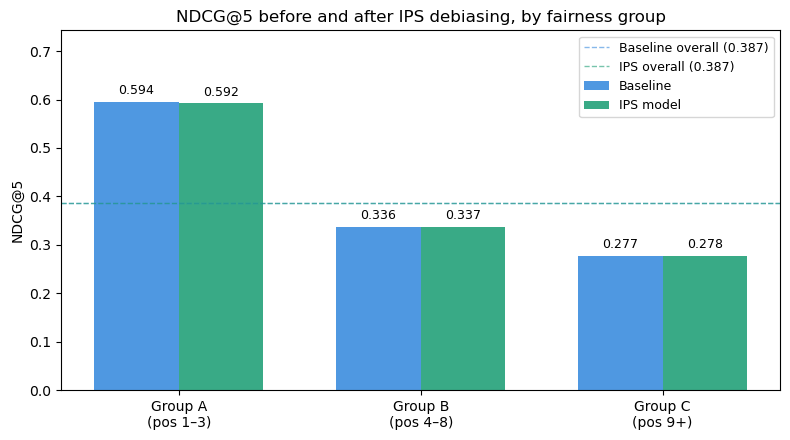

Saved: bias_comparison.png


In [26]:
groups_plot = ["A (pos 1–3)", "B (pos 4–10)", "C (pos 11+)"]
x = np.arange(len(groups_plot))
w = 0.35
 
fig, ax = plt.subplots(figsize=(8, 4.5))
bars1 = ax.bar(x - w/2, [scores_base[g] for g in groups_plot], w,
               label="Baseline",  color="#378ADD", alpha=0.88)
bars2 = ax.bar(x + w/2, [scores_ips[g]  for g in groups_plot], w,
               label="IPS model", color="#1D9E75", alpha=0.88)
 
ax.axhline(scores_base["Overall"], color="#378ADD", linestyle="--",
           linewidth=1.0, alpha=0.6,
           label=f"Baseline overall ({scores_base['Overall']:.3f})")
ax.axhline(scores_ips["Overall"],  color="#1D9E75", linestyle="--",
           linewidth=1.0, alpha=0.6,
           label=f"IPS overall ({scores_ips['Overall']:.3f})")
 
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
            f"{h:.3f}", ha="center", va="bottom", fontsize=9)
 
ax.set_xticks(x)
ax.set_xticklabels(["Group A\n(pos 1–3)", "Group B\n(pos 4–8)", "Group C\n(pos 9+)"])
ax.set_ylabel("NDCG@5")
ax.set_title("NDCG@5 before and after IPS debiasing, by fairness group")
ax.set_ylim(0, min(1.1, max(scores_base.values()) * 1.25))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("bias_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: bias_comparison.png")

## 17 · Training: add inverse propensity as a feature

In [ ]:
# Build debiased training dataset
FEATURES_DEBIAS = FEATURES + ["inv_propensity"]

df_train_debias = df_train_s.copy()
df_train_debias["inv_propensity"] = (
    1.0 / df_train_debias["position"].clip(lower=1)
).astype("float32")

X_debias      = df_train_debias[FEATURES_DEBIAS]
y_debias      = df_train_debias["relevance"]
groups_debias = df_train_debias.groupby("srch_id", sort=False).size().values

lgb_debias = lgb.Dataset(
    X_debias, label=y_debias,
    group=groups_debias, free_raw_data=False,
)

# Rebuild val dataset with the same 63 features 
# inv_propensity = 1.0 simulates equal examination (no position advantage)
X_val_debias = df_val[FEATURES].copy()
X_val_debias["inv_propensity"] = np.float32(1.0)

lgb_val_debias = lgb.Dataset(
    X_val_debias,
    label=df_val["relevance"].values,
    group=df_val.groupby("srch_id", sort=False).size().values,
    reference=lgb_debias,   # ensures same feature encoding as train
    free_raw_data=False,
)

# Train 
model_debias = lgb.train(
    bias_params, lgb_debias,
    num_boost_round=500,
    valid_sets=[lgb_val_debias], valid_names=["val"],
    callbacks=silent_cb,
)

# Evaluate
df_val_debias = df_val_grp.copy()
df_val_debias["inv_propensity"] = np.float32(1.0)

scores_debias = ndcg5_by_group(model_debias, df_val_debias,
                               features=FEATURES_DEBIAS)

print(f"{'Group':<16} {'Baseline':>10} {'Debias':>10} {'Δ':>8}")
print("─" * 48)
for grp in sorted(scores_base.keys()):
    delta = scores_debias[grp] - scores_base[grp]
    arrow = "▲" if delta > 0.001 else ("▼" if delta < -0.001 else "—")
    print(f"{grp:<16} {scores_base[grp]:>10.4f} "
          f"{scores_debias[grp]:>10.4f}  {arrow}{abs(delta):.4f}")

Group              Baseline     Debias        Δ
────────────────────────────────────────────────
A (pos 1–3)          0.5943     0.5914  ▼0.0029
B (pos 4–10)         0.3363     0.3388  ▲0.0025
C (pos 11+)          0.2768     0.2782  ▲0.0013
Overall              0.3871     0.3873  —0.0003


## 20 · Report-ready summary

In [ ]:
print()
print("DETECTION")
print(f"  Kendall τ (position vs click_bool)   : {tau_c:.4f}  p={p_c:.2e}")
print(f"  Kendall τ (position vs booking_bool) : {tau_b:.4f}  p={p_b:.2e}")
print()
print("MITIGATION")
print("  Pre-processing: Inverse Propensity Scoring (IPS)")
print("  Reference: Joachims et al. (2017), WSDM")
print("  propensity(k) = 1/k  →  ips_weight(k) = k  (clipped at 10, normalised per search)")
print()
print("EFFECTIVENESS")
for grp in sorted(scores_base.keys()):
    delta = scores_debias[grp] - scores_base[grp]
    direction = "improved" if delta > 0 else "declined"
    print(f"  {grp:<16}: {scores_base[grp]:.4f} → {scores_debias[grp]:.4f} "
          f"({direction} by {abs(delta):.4f})")


── Section 7: Report-ready summary ────────────────────────────────

DETECTION
  Kendall τ (position vs click_bool)   : -0.1425  p=0.00e+00
  Kendall τ (position vs booking_bool) : -0.1282  p=0.00e+00

MITIGATION
  Pre-processing: Inverse Propensity Scoring (IPS)
  Reference: Joachims et al. (2017), WSDM
  propensity(k) = 1/k  →  ips_weight(k) = k  (clipped at 10, normalised per search)

EFFECTIVENESS
  A (pos 1–3)     : 0.5943 → 0.5914 (declined by 0.0029)
  B (pos 4–10)    : 0.3363 → 0.3388 (improved by 0.0025)
  C (pos 11+)     : 0.2768 → 0.2782 (improved by 0.0013)
  Overall         : 0.3871 → 0.3873 (improved by 0.0003)


## 21 · Generate submission file (debiased)

In [ ]:
# Load test features
test_cols   = pd.read_csv("test_features.csv", nrows=0).columns.tolist()
test_dtypes = {c: np.float32 for c in test_cols
               if c not in {"srch_id", "prop_id"}}

print("Loading test_features.csv ...")
test_df = pd.read_csv("test_features.csv", dtype=test_dtypes)
print(f"  shape : {test_df.shape}")

# Add inv_propensity = 1.0 for all test rows 
# Position is unknown at test time — setting to 1.0 asks the model to rank
# purely on intrinsic hotel quality with no position advantage applied
test_df["inv_propensity"] = np.float32(1.0)

# Score with debiased model 
X_test_debias = test_df[FEATURES_DEBIAS]   # 63 features including inv_propensity
test_df["pred_score"] = model_debias.predict(X_test_debias)

# Rank and write submission 
submission = (
    test_df[["srch_id", "prop_id", "pred_score"]]
    .sort_values(["srch_id", "pred_score"], ascending=[True, False])
    .drop(columns=["pred_score"])
    .rename(columns={"srch_id": "SearchId", "prop_id": "PropertyId"})
    .reset_index(drop=True)
)

submission.to_csv("submission_debias.csv", index=False)
print(f"\nSaved : submission_debias.csv")
print(f"  Rows     : {len(submission):,}")
print(f"  Searches : {submission['SearchId'].nunique():,}")
print(submission.head(12).to_string(index=False))

Loading test_features.csv ...
  shape : (4959183, 64)

Saved : submission_debias.csv
  Rows     : 4,959,183
  Searches : 199,549
 SearchId  PropertyId
        1       99484
        1       54937
        1       61934
        1       28181
        1       24194
        1       34263
        1       82231
        1       63894
        1       50162
        1       90385
        1       72090
        1       74045
